In [9]:
import os

import matplotlib.pyplot as plt
import numpy as np
import polars as pl
import pandas as pd

In [12]:
# JAL1 SEQ3
JAL1_SEQ3_cluster_matrix = r"Z:\Jasmine_Laurence\Experimental_Data\JAL001\001_seq1_3_2023_03_17T08_38_03\processed_data\frame_by_good_cluster_matrix.npy"

# JAL1 SEQ2
JAL1_SEQ2_cluster_matrix = r"Z:\Jasmine_Laurence\Experimental_Data\JAL001\001_seq1_2_2023_03_14T08_11_32\processed_data\frame_by_good_cluster_matrix.npy" 

# -------

# JAl2 SEQ3
JAL2_SEQ3_cluster_matrix =  r"Z:\Jasmine_Laurence\Experimental_Data\JAL002\002_Sequence1_3_2023_04_28T08_31_30\processed_data\frame_by_good_cluster_matrix.npy"

# JAL2 SEQ2
JAL2_SEQ2_cluster_matrix =  r"Z:\Jasmine_Laurence\Experimental_Data\JAL002\002_seq1_2_2023_04_25T07_32_30\processed_data\frame_by_good_cluster_matrix.npy"

# JAL2 22nd April
jal2_22nd_april = pd.read_csv(r"Z:\Jasmine_Laurence\Experimental_Data\JAL002\002_Sequence1_2023_04_22T08_38_41\processed_data\spike_count_by_frame_and_goodcluster.csv")
jal2_unique_clusters = len(jal2_22nd_april["spike_clusters"].unique())

# load the cluster matrices
jal2_seq3 = np.load(JAL2_SEQ3_cluster_matrix)
jal1_seq3 = np.load(JAL1_SEQ3_cluster_matrix)
jal1_seq2 = np.load(JAL1_SEQ2_cluster_matrix)
jal2_seq2 = np.load(JAL2_SEQ2_cluster_matrix)


In [14]:
print("JAL2 SEQ3 shape:", jal2_seq3.shape)
print("JAL1 SEQ3 shape:", jal1_seq3.shape)
print("JAL1 SEQ2 shape:", jal1_seq2.shape)
print("JAL2 SEQ2 shape:", jal2_seq2.shape)

JAL2 SEQ3 shape: (332686, 91)
JAL1 SEQ3 shape: (275586, 48)
JAL1 SEQ2 shape: (242566, 48)
JAL2 SEQ2 shape: (343294, 85)


In [18]:
save_path = r"Z:\Laurence\thesis\figures\two_edge_paradigm"

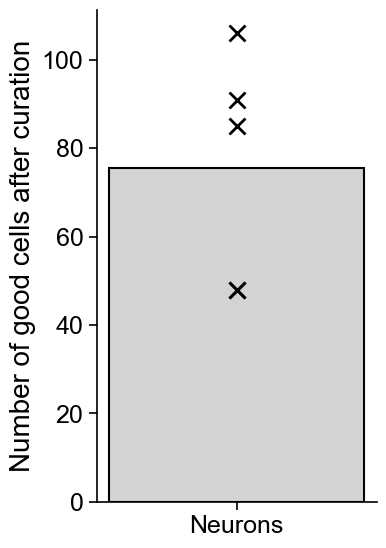

In [25]:
import matplotlib.pyplot as plt
import numpy as np

# Number of good cells for each session (last dimension of each matrix)
n_good_cells = [
    jal2_seq3.shape[-1],
    jal1_seq3.shape[-1],
    jal1_seq2.shape[-1],
    jal2_seq2.shape[-1],
    jal2_unique_clusters  # For the 22nd April session
]

# Calculate mean and SEM
mean_cells = np.mean(n_good_cells)
sem_cells = np.std(n_good_cells, ddof=1) / np.sqrt(len(n_good_cells))

plt.rcParams.update({
    "font.size": 18,
    "font.family": "Arial",
    "axes.labelsize": 20,
    "axes.titlesize": 22,
    "xtick.labelsize": 18,
    "ytick.labelsize": 18,
    "legend.fontsize": 16,
})

fig, ax = plt.subplots(figsize=(4, 6))

# Plot the bar (mean)
bar = ax.bar(
    ["Neurons"], [mean_cells],
    color="lightgrey", edgecolor="black", linewidth=1.5, capsize=10, width=0.6
)

# Plot crosses for each session
for val in n_good_cells:
    ax.plot(0, val, marker='x', color='black', markersize=12, markeredgewidth=2)

ax.set_ylabel("Number of good cells after curation")
ax.set_xticks([0])
ax.set_xticklabels(["Neurons"])
ax.spines["top"].set_visible(False)
ax.spines["right"].set_visible(False)
ax.spines["left"].set_linewidth(1.2)
ax.spines["bottom"].set_linewidth(1.2)
ax.tick_params(width=1.2, length=6)
plt.tight_layout(pad=0.5)
plt.subplots_adjust(left=0.25, right=0.95, bottom=0.13, top=0.95)
plt.show()

fig.savefig(os.path.join(save_path, "good_neuron_count.eps"), format='eps', bbox_inches='tight', dpi=300)